In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
category_tree=pd.read_csv('category_tree.csv')

In [3]:
category_tree.shape

(1669, 2)

In [4]:
category_tree.info()

<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [5]:
category_tree.describe()

,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


In [6]:
category_tree.head(10)

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0
7,1146,542.0
8,1140,542.0
9,1479,1537.0


In [7]:
category_tree.duplicated().sum()

np.int64(0)

# Category Tree Overview

The `category_tree` dataset defines the hierarchical structure of product categories. It serves as a lookup table that links each product category to its parent category, enabling category-level analysis throughout the project.

### Dataset Summary

- **Rows:** 1,669
- **Columns:** 2 (`categoryid`, `parentid`)
- **Root Categories:** 25 (`parentid` is null)
- **Child Categories:** 1,644

### Data Quality Checks

#### Missing Values

- `parentid` contains **25 missing values**, which represent **root-level categories** rather than incomplete or erroneous data.
- No data cleaning is required for these records.

#### Duplicate Check

**Output:** `0`

**Observation:**

- No duplicate records were found.
- Each `categoryid` is unique, ensuring a consistent category hierarchy.
- This prevents duplicate category mappings when joining with product data and supports reliable category-level analysis.


In [8]:
# events csv data overview
events=pd.read_csv('events.csv')

In [9]:
events.shape

(2756101, 5)

In [10]:
events.head(10)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


In [11]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 116.1 MB


In [12]:
events.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [13]:
events.describe(include='all')

,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


In [14]:
events.duplicated().sum()

np.int64(460)

In [15]:
events=events.drop_duplicates()
events

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


In [16]:
events.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733184
dtype: int64

In [17]:
#event counts-
events["event"].value_counts()

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

In [18]:
events["event"].value_counts(normalize=True) * 100

event
view           96.682333
addtocart       2.502721
transaction     0.814947
Name: proportion, dtype: float64

In [19]:
#unique visitors-
events["visitorid"].nunique()

1407580

In [20]:
#unique products viewed
events["itemid"].nunique()

235061

In [21]:
# time range
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")
events

,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,2015-08-01 03:13:05.939,591435,view,261427,NaN
2756097,2015-08-01 03:30:13.142,762376,view,115946,NaN
2756098,2015-08-01 02:57:00.527,1251746,view,78144,NaN
2756099,2015-08-01 03:08:50.703,1184451,view,283392,NaN


In [22]:
print(events["timestamp"].min(),events["timestamp"].max())

2015-05-03 03:00:04.384000 2015-09-18 02:59:47.788000


In [23]:
#kpi 
total_events = len(events)

unique_visitors = events["visitorid"].nunique()

unique_products = events["itemid"].nunique()

views = (events["event"]=="view").sum()

cart = (events["event"]=="addtocart").sum()

transactions = (events["event"]=="transaction").sum()

# Events Dataset Overview

The `events` dataset is the primary behavioral event log of the e-commerce platform. Each row represents a single interaction performed by a visitor, enabling end-to-end analysis of user behavior, product engagement, conversion funnels, and purchasing patterns.

## Dataset Summary

| Metric | Value |
|--------|------:|
| Total Events | 2,755,641 |
| Unique Visitors | 1,407,580 |
| Unique Products | 235,061 |
| Analysis Period | 03 May 2015 – 18 Sep 2015 |
| Event Types | 3 |

---

## Event Types

| Event | Count | Share |
|--------|------:|------:|
| View | 2,664,218 | 96.68% |
| Add to Cart | 68,966 | 2.50% |
| Transaction | 22,457 | 0.81% |

### Business Observation

The event distribution follows a typical e-commerce purchase funnel:

- Nearly all user interactions are product views.
- Only a small percentage progress to adding products to the cart.
- Less than 1% of recorded events are completed purchases.

This immediately highlights the importance of analyzing funnel drop-offs and conversion optimization throughout the project.

---

## Data Quality Assessment

### Duplicate Records

**Before Cleaning:** 460 duplicate rows

These duplicate records were removed to prevent inflated event counts and inaccurate behavioral metrics.

---

### Missing Values

| Column | Missing Values | Interpretation |
|---------|---------------:|---------------|
| timestamp | 0 | Complete |
| visitorid | 0 | Complete |
| event | 0 | Complete |
| itemid | 0 | Complete |
| transactionid | 2,733,184 | Expected |

The missing values in `transactionid` are expected because transaction IDs are generated only for purchase events. Missing values therefore represent non-purchase interactions rather than incomplete data.

---

## Time Coverage

The behavioral data spans:

**03 May 2015 → 18 September 2015**

Approximately **4.5 months** of continuous user activity, making it suitable for analyzing user behavior, product engagement, retention, and conversion trends over time.

---

In [24]:
#item properties csv
item_properties_part1=pd.read_csv('item_properties_part1.csv')

In [25]:
item_properties_part1.shape

(10999999, 4)

In [26]:
item_properties_part2=pd.read_csv('item_properties_part2.csv')

In [27]:
item_properties_part2.shape

(9275903, 4)

In [28]:
# adding these both df
item_properties = pd.concat([item_properties_part1, item_properties_part2],ignore_index=True)
item_properties.shape

(20275902, 4)

In [29]:
del item_properties_part1
del item_properties_part2

In [30]:
item_properties.shape

(20275902, 4)

In [31]:
item_properties.info()

<class 'pandas.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   timestamp  int64
 1   itemid     int64
 2   property   str  
 3   value      str  
dtypes: int64(2), str(2)
memory usage: 1.0 GB


In [32]:
item_properties.describe()

,timestamp,itemid
count,2.027590e+07,2.027590e+07
mean,1.435157e+12,2.333904e+05
std,3.327798e+09,1.348452e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165160e+05
50%,1.433646e+12,2.334830e+05
75%,1.437880e+12,3.503040e+05
max,1.442113e+12,4.668660e+05


In [33]:
item_properties.describe(include='object')

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32039/3755690944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  item_properties.describe(include='object')


,property,value
count,20275902,20275902
unique,1104,1966868
top,888,769062
freq,3000398,1537247


In [34]:
item_properties.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [35]:
item_properties.isnull().sum()

timestamp    0
itemid       0
property     0
value        0
dtype: int64

In [36]:
item_properties.duplicated().sum()

np.int64(0)

In [37]:
item_properties.nunique()

timestamp         18
itemid        417053
property        1104
value        1966868
dtype: int64

In [38]:
item_properties['property'].value_counts().head(20)

property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
159            417053
764            417053
112            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64

In [39]:
print(item_properties['timestamp'].min(),item_properties['timestamp'].max())

1431226800000 1442113200000


In [40]:
item_properties['timestamp']=pd.to_datetime(item_properties['timestamp'],unit='ms')
item_properties

,timestamp,itemid,property,value
0,2015-06-28 03:00:00,460429,categoryid,1338
1,2015-09-06 03:00:00,206783,888,1116713 960601 n277.200
2,2015-08-09 03:00:00,395014,400,n552.000 639502 n720.000 424566
3,2015-05-10 03:00:00,59481,790,n15360.000
4,2015-05-17 03:00:00,156781,917,828513
...,...,...,...,...
20275897,2015-06-07 03:00:00,236931,929,n12.000
20275898,2015-08-30 03:00:00,455746,6,150169 639134
20275899,2015-08-16 03:00:00,347565,686,610834
20275900,2015-06-07 03:00:00,287231,867,769062


In [41]:
print(item_properties['timestamp'].min(),item_properties['timestamp'].max())

2015-05-10 03:00:00 2015-09-13 03:00:00


# Product Properties Overview

The `item_properties` dataset contains the historical metadata of every product in the catalog.

Unlike a traditional product master table, this dataset stores **time-based snapshots**, meaning each row represents the value of a particular product property at a specific point in time.

This enables tracking how product attributes changed throughout the observation period.

## Dataset Summary

| Metric | Value |
|---------|------:|
| Total Records | 20,275,902 |
| Unique Products | 417,053 |
| Unique Properties | 1,104 |
| Unique Property Values | 1,966,868 |
| Snapshot Dates | 18 |
| Observation Period | 10 May 2015 – 13 Sep 2015 |

---

## Data Quality Assessment

### Duplicate Check

```python
item_properties.duplicated().sum()
```

**Output:** `0`

No duplicate records were identified.

---

### Missing Values

```python
item_properties.isnull().sum()
```

No missing values were found in any column, indicating a complete product metadata history.

---

## Structural Observations

- Each product appears multiple times because product attributes are recorded as historical snapshots.
- The dataset is **not** one row per product.
- Product attributes (such as category, availability, and other hashed properties) evolve over time.
- A total of **18 snapshot dates** are available, allowing analysis of product catalog changes during the study period.

---

## Important Product Properties

Some properties are directly interpretable:

- **categoryid** → Product category
- **available** → Product availability (0/1)

The remaining properties are hashed identifiers supplied by the dataset provider. Although their business meaning is unknown, they can still be analyzed as product features if needed.

---

## Business Importance

This dataset serves as the **product dimension** for the entire analytics project.

Before any product-level analysis, it will be transformed into a **Product Master Table** by:

- Selecting the latest available snapshot for each product
- Extracting category information
- Extracting product availability
- Removing historical duplicates
- Creating one record per product

This transformed table will later be joined with user events to support funnel analysis, category performance, conversion analysis, and product strategy recommendations.

In [42]:
#Latest Snapshot
product_master = item_properties.sort_values("timestamp").drop_duplicates(subset=["itemid", "property"],keep="last")
product_master

,timestamp,itemid,property,value
5668945,2015-05-10 03:00:00,422842,480,1133979
11314219,2015-05-10 03:00:00,310185,776,103591
15170322,2015-05-10 03:00:00,110973,112,679677
15170323,2015-05-10 03:00:00,179597,available,0
11314209,2015-05-10 03:00:00,138592,764,1285872
...,...,...,...,...
9472989,2015-09-13 03:00:00,364708,928,769062
9473006,2015-09-13 03:00:00,231604,888,561561 1055803 447378 n12.000 1135780 1284577 ...
2199697,2015-09-13 03:00:00,161357,888,12762 16970 145048 237874 1229126 784581 12977...
9472887,2015-09-13 03:00:00,267142,available,0


In [43]:
#Extract Category
category =product_master[product_master["property"] == "categoryid"][["itemid", "value"]].rename(columns={"value": "categoryid"})

category["categoryid"] = category["categoryid"].astype(int)
category

,itemid,categoryid
5668929,385184,769
5668917,299303,1441
17720281,393519,279
8545980,22620,1483
2777328,91333,991
...,...,...
9473723,190433,282
9475155,336196,205
19284798,382822,706
16000898,70193,438


In [44]:
#Extract Availability
availability = product_master.loc[product_master["property"] == "available",["itemid", "value"]].rename(columns={"value": "available"})

availability["available"] = availability["available"].astype(int)
availability

,itemid,available
15170323,179597,0
16420881,175991,0
15170313,323647,0
11314181,415259,0
11314168,312215,0
...,...,...
16001557,222125,0
19284758,239342,1
16001535,222103,0
9472944,266755,0


In [45]:
#Build Product Dimension
product_dimension = (
    category
    .merge(availability,
           on="itemid",
           how="left")
    .merge(category_tree,
           on="categoryid",
           how="left")
)
product_dimension

,itemid,categoryid,available,parentid
0,385184,769,1,587.0
1,299303,1441,1,1566.0
2,393519,279,0,777.0
3,22620,1483,0,561.0
4,91333,991,0,1259.0
...,...,...,...,...
417048,190433,282,0,113.0
417049,336196,205,0,381.0
417050,382822,706,0,713.0
417051,70193,438,0,312.0


In [46]:
product_dimension.info()

<class 'pandas.DataFrame'>
RangeIndex: 417053 entries, 0 to 417052
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   itemid      417053 non-null  int64  
 1   categoryid  417053 non-null  int64  
 2   available   417053 non-null  int64  
 3   parentid    416896 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 12.7 MB


In [47]:
#Number of Categories
product_dimension["categoryid"].nunique()

1180

In [48]:
#Products per Category
products_per_category =product_dimension.groupby("categoryid").agg(products=("itemid","nunique")).sort_values("products",ascending=False)

products_per_category

,products
categoryid,
342,17231
769,10982
173,10561
1301,9943
1007,9737
...,...
788,1
1597,1
791,1


In [49]:
# largest 10 categories
products_per_category.head(10)

,products
categoryid,
342,17231
769,10982
173,10561
1301,9943
1007,9737
1142,6818
1680,6019
1250,5193
1070,4209


In [50]:
#Availability Status
product_dimension["available"].value_counts()

available
0    363043
1     54010
Name: count, dtype: int64

In [51]:
product_dimension["available"].value_counts(normalize=True).mul(100).round(2)

available
0    87.05
1    12.95
Name: proportion, dtype: float64

In [52]:
#Catalog Engagement-

#Unique products in catalog
catalog_products = product_dimension["itemid"].nunique()

#Products with any interaction
engaged_products = events["itemid"].nunique()

#Products never interacted
never_engaged = (catalog_products- engaged_products)

#Coverage
coverage = (engaged_products/ catalog_products*100)
coverage

56.36238080052176

In [53]:
pd.DataFrame({"Metric":["Catalog Products","Products With Interaction","Products Without Interaction","Catalog Coverage (%)"],

"Value":[catalog_products,engaged_products,never_engaged,round(coverage,2)]})

,Metric,Value
0,Catalog Products,417053.00
1,Products With Interaction,235061.00
2,Products Without Interaction,181992.00
3,Catalog Coverage (%),56.36


In [54]:
#Category Engagement (Merge events with category)
events_category = events.merge(product_dimension[["itemid","categoryid"]], on="itemid", how="left")
events_category

,timestamp,visitorid,event,itemid,transactionid,categoryid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN,1173.0
1,2015-06-02 05:50:14.164,992329,view,248676,NaN,1231.0
2,2015-06-02 05:13:19.827,111016,view,318965,NaN,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN,914.0
4,2015-06-02 05:02:17.106,951259,view,367447,NaN,491.0
...,...,...,...,...,...,...
2755636,2015-08-01 03:13:05.939,591435,view,261427,NaN,1623.0
2755637,2015-08-01 03:30:13.142,762376,view,115946,NaN,1616.0
2755638,2015-08-01 02:57:00.527,1251746,view,78144,NaN,969.0
2755639,2015-08-01 03:08:50.703,1184451,view,283392,NaN,1589.0


In [55]:
#Views
views_by_category = (events_category[events_category['event']=='view'].groupby("categoryid").agg(Views=("itemid","count"))
.sort_values("Views",ascending=False))
views_by_category

,Views
categoryid,
1051.0,73014
1483.0,62785
491.0,59298
959.0,50112
342.0,45288
...,...
1345.0,1
1546.0,1
732.0,1


In [56]:
#Add to cart
cart_by_category = (events_category.query("event=='addtocart'").groupby("categoryid").agg(Add_to_Cart=("itemid","count"))
.sort_values("Add_to_Cart",ascending=False))
cart_by_category

,Add_to_Cart
categoryid,
1051.0,1709
959.0,1633
491.0,1548
1483.0,1520
342.0,1278
...,...
907.0,1
1193.0,1
1620.0,1


In [57]:
#Transactions
transactions_by_category = (events_category.query("event=='transaction'").groupby("categoryid").agg(Transactions=("itemid","count"))
    .sort_values("Transactions",ascending=False))
transactions_by_category

,Transactions
categoryid,
959.0,532
1051.0,485
1483.0,469
196.0,298
1542.0,294
...,...
1540.0,1
1536.0,1
1217.0,1


In [58]:
#category funnel 
category_funnel = events_category.groupby(["categoryid","event"]).size().unstack(fill_value=0).reset_index()
category_funnel = category_funnel.rename(columns={"view":"Views","addtocart":"Add_to_Cart", "transaction":"Transactions"})
category_funnel

event,categoryid,Add_to_Cart,Transactions,Views
0,0.0,58,12,1049
1,1.0,391,80,5846
2,3.0,58,15,2375
3,4.0,12,10,144
4,5.0,576,186,28952
...,...,...,...,...
1081,1689.0,0,0,19
1082,1690.0,27,5,1125
1083,1694.0,94,44,5557
1084,1695.0,0,0,62


In [59]:
# conversion rates
category_funnel["View_to_Cart_%"] = (category_funnel["Add_to_Cart"]/category_funnel["Views"] *100).round(2)

category_funnel["Cart_to_Purchase_%"] = (category_funnel["Transactions"]/category_funnel["Add_to_Cart"]*100).round(2)

category_funnel["View_to_Purchase_%"] = (category_funnel["Transactions"]/category_funnel["Views"]*100).round(2)

print('View_to_Cart_%:',category_funnel["View_to_Cart_%"],'\nCart_to_Purchase_%:',category_funnel["Cart_to_Purchase_%"],
      '\nView_to_Purchase_%:',category_funnel["View_to_Purchase_%"])

View_to_Cart_%: 0       5.53
1       6.69
2       2.44
3       8.33
4       1.99
        ... 
1081    0.00
1082    2.40
1083    1.69
1084    0.00
1085    0.00
Name: View_to_Cart_%, Length: 1086, dtype: float64 
Cart_to_Purchase_%: 0       20.69
1       20.46
2       25.86
3       83.33
4       32.29
        ...  
1081      NaN
1082    18.52
1083    46.81
1084      NaN
1085      NaN
Name: Cart_to_Purchase_%, Length: 1086, dtype: float64 
View_to_Purchase_%: 0       1.14
1       1.37
2       0.63
3       6.94
4       0.64
        ... 
1081    0.00
1082    0.44
1083    0.79
1084    0.00
1085    0.00
Name: View_to_Purchase_%, Length: 1086, dtype: float64


In [60]:
#Top Categories by transactions
category_funnel.sort_values("Transactions",ascending=False).head(20)

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
615,959.0,1633,532,50112,3.26,32.58,1.06
676,1051.0,1709,485,73014,2.34,28.38,0.66
961,1483.0,1520,469,62785,2.42,30.86,0.75
126,196.0,740,298,26645,2.78,40.27,1.12
994,1542.0,662,294,12853,5.15,44.41,2.29
407,618.0,709,285,14535,4.88,40.20,1.96
222,342.0,1278,281,45288,2.82,21.99,0.62
322,491.0,1548,263,59298,2.61,16.99,0.44
746,1163.0,372,259,7157,5.20,69.62,3.62
920,1421.0,613,246,9376,6.54,40.13,2.62


In [61]:
#Top Categories by view
category_funnel.sort_values("Views",ascending=False).head(20)

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
676,1051.0,1709,485,73014,2.34,28.38,0.66
961,1483.0,1520,469,62785,2.42,30.86,0.75
322,491.0,1548,263,59298,2.61,16.99,0.44
615,959.0,1633,532,50112,3.26,32.58,1.06
222,342.0,1278,281,45288,2.82,21.99,0.62
445,683.0,907,211,37765,2.40,23.26,0.56
823,1279.0,720,123,33531,2.15,17.08,0.37
4,5.0,576,186,28952,1.99,32.29,0.64
426,646.0,484,87,27669,1.75,17.98,0.31
32,48.0,600,146,26701,2.25,24.33,0.55


In [62]:
#Top Categories by view to cart
category_funnel[category_funnel['Views']>1000].sort_values("View_to_Cart_%",ascending=False).head(20)

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
830,1286.0,284,57,1736,16.36,20.07,3.28
281,434.0,623,134,4356,14.30,21.51,3.08
666,1037.0,652,226,5189,12.57,34.66,4.36
209,320.0,197,26,1632,12.07,13.20,1.59
762,1191.0,327,78,2752,11.88,23.85,2.83
844,1305.0,243,39,2120,11.46,16.05,1.84
270,417.0,205,82,1914,10.71,40.00,4.28
966,1493.0,438,155,4277,10.24,35.39,3.62
411,624.0,431,144,5044,8.54,33.41,2.85
625,972.0,164,74,1975,8.30,45.12,3.75


In [63]:
# top categories by view to purchase
category_funnel[category_funnel['Views']>1000].sort_values("View_to_Purchase_%",ascending=False).head(20)

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
37,57.0,128,150,2229,5.74,117.19,6.73
666,1037.0,652,226,5189,12.57,34.66,4.36
270,417.0,205,82,1914,10.71,40.00,4.28
448,686.0,422,236,6052,6.97,55.92,3.90
625,972.0,164,74,1975,8.30,45.12,3.75
966,1493.0,438,155,4277,10.24,35.39,3.62
746,1163.0,372,259,7157,5.20,69.62,3.62
670,1043.0,66,63,1893,3.49,95.45,3.33
830,1286.0,284,57,1736,16.36,20.07,3.28
281,434.0,623,134,4356,14.30,21.51,3.08


In [64]:
# Minimum traffic threshold
MIN_VIEWS = 1000

category_analysis = category_funnel[category_funnel["Views"] >= MIN_VIEWS].copy()

In [66]:
#Worst High-Traffic Categories
high_traffic = category_analysis[category_analysis["Views"] >= category_analysis["Views"].quantile(0.75)]

worst_high_traffic = high_traffic.sort_values("View_to_Purchase_%").head(15)
worst_high_traffic

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
512,789.0,62,8,7988,0.78,12.90,0.10
958,1477.0,187,14,13370,1.40,7.49,0.10
858,1325.0,47,7,6243,0.75,14.89,0.11
328,499.0,266,16,13440,1.98,6.02,0.12
759,1188.0,98,14,8044,1.22,14.29,0.17
42,64.0,248,22,10566,2.35,8.87,0.21
532,818.0,67,15,6618,1.01,22.39,0.23
278,429.0,105,30,12917,0.81,28.57,0.23
643,999.0,33,14,5955,0.55,42.42,0.24
426,646.0,484,87,27669,1.75,17.98,0.31


In [67]:
#Hidden Gems
hidden_gems = category_analysis[(category_analysis["Views"] <= category_analysis["Views"].quantile(0.25)) &
    (category_analysis["View_to_Purchase_%"] >= category_analysis["View_to_Purchase_%"].quantile(0.75))]

hidden_gems = hidden_gems.sort_values("View_to_Purchase_%",ascending=False)

hidden_gems.head(15)

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%
830,1286.0,284,57,1736,16.36,20.07,3.28
884,1366.0,77,35,1185,6.50,45.45,2.95
306,470.0,106,51,1786,5.94,48.11,2.86
1002,1554.0,69,35,1228,5.62,50.72,2.85
710,1103.0,78,44,1653,4.72,56.41,2.66
889,1376.0,42,27,1068,3.93,64.29,2.53
669,1040.0,129,44,1775,7.27,34.11,2.48
394,596.0,75,33,1369,5.48,44.00,2.41
133,208.0,76,35,1526,4.98,46.05,2.29
223,343.0,48,33,1438,3.34,68.75,2.29


In [68]:
#Category Opportunity Matrix
median_views = category_analysis["Views"].median()
median_conversion = category_analysis["View_to_Purchase_%"].median()

def classify(row):

    if row["Views"] >= median_views and row["View_to_Purchase_%"] >= median_conversion:
        return "Star Category"

    elif row["Views"] >= median_views and row["View_to_Purchase_%"] < median_conversion:
        return "Optimize Conversion"

    elif row["Views"] < median_views and row["View_to_Purchase_%"] >= median_conversion:
        return "Hidden Gem"

    else:
        return "Low Priority"

category_analysis["Opportunity"] = category_analysis.apply(classify, axis=1)

In [69]:
#Count categories in each quadrant
category_analysis["Opportunity"].value_counts()

Opportunity
Hidden Gem             107
Optimize Conversion    104
Star Category          101
Low Priority            98
Name: count, dtype: int64

In [70]:
#View categories by quadrant
category_analysis.sort_values(["Opportunity", "View_to_Purchase_%"],ascending=[True, False])

event,categoryid,Add_to_Cart,Transactions,Views,View_to_Cart_%,Cart_to_Purchase_%,View_to_Purchase_%,Opportunity
37,57.0,128,150,2229,5.74,117.19,6.73,Hidden Gem
270,417.0,205,82,1914,10.71,40.00,4.28,Hidden Gem
625,972.0,164,74,1975,8.30,45.12,3.75,Hidden Gem
670,1043.0,66,63,1893,3.49,95.45,3.33,Hidden Gem
830,1286.0,284,57,1736,16.36,20.07,3.28,Hidden Gem
...,...,...,...,...,...,...,...,...
822,1277.0,109,35,4189,2.60,32.11,0.84,Star Category
977,1511.0,200,64,7652,2.61,32.00,0.84,Star Category
765,1196.0,157,39,4682,3.35,24.84,0.83,Star Category
614,958.0,105,30,3638,2.89,28.57,0.82,Star Category


In [71]:
opportunity_summary = (category_analysis.groupby("Opportunity").agg(
        Categories=("categoryid", "count"),
        Avg_Views=("Views", "mean"),
        Avg_View_to_Purchase=("View_to_Purchase_%", "mean"),
        Total_Transactions=("Transactions", "sum") ).round(2))

opportunity_summary

,Categories,Avg_Views,Avg_View_to_Purchase,Total_Transactions
Opportunity,,,,
Hidden Gem,107,1851.36,1.63,3254
Low Priority,98,1829.57,0.41,737
Optimize Conversion,104,10574.57,0.48,5738
Star Category,101,7623.85,1.47,10673


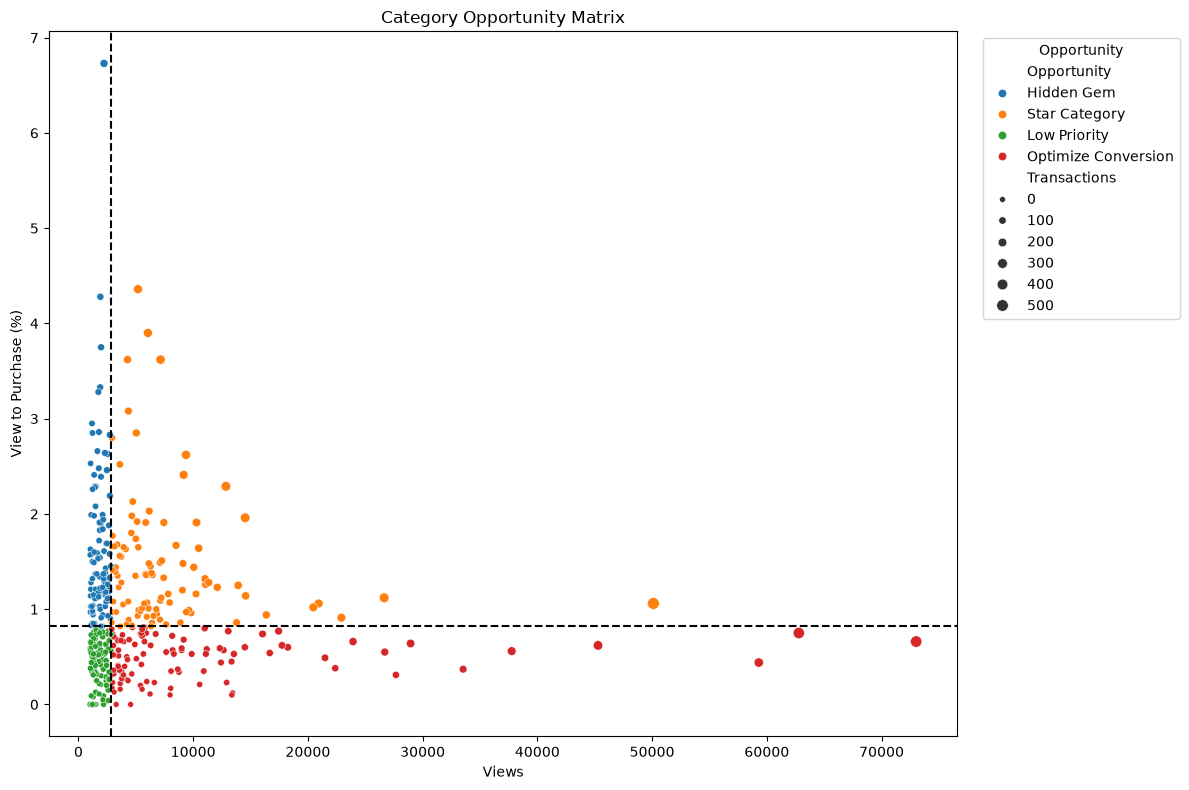

In [72]:
plt.figure(figsize=(12,8))
views_threshold = category_analysis["Views"].median()
conversion_threshold = category_analysis["View_to_Purchase_%"].median()

sns.scatterplot(data=category_analysis, x='Views',y='View_to_Purchase_%', hue='Opportunity',size='Transactions')


plt.axvline(views_threshold, color="black", linestyle="--")
plt.axhline(conversion_threshold, color="black", linestyle="--")

plt.title("Category Opportunity Matrix")
plt.xlabel("Views")
plt.ylabel("View to Purchase (%)")
plt.legend(title="Opportunity",bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.savefig('Category Opportunity Matrix.png',dpi=400)
plt.show()

# Category Performance Analysis

After mapping every product to its corresponding category, category-level funnel metrics were calculated to understand how different product categories contribute to customer acquisition, engagement, and purchases.

The objective was to identify:

- Which categories attract the most customer attention
- Which categories generate the highest sales
- Which categories successfully convert visitors into buyers
- Which categories underperform despite receiving significant traffic
- Hidden growth opportunities across the product catalog

---

# Opportunity Matrix

Each category was segmented using two business dimensions:

- **Traffic (Views)**
- **Conversion Efficiency (View → Purchase %)**

This resulted in four strategic category groups.

| Opportunity | Categories | Avg Views | Avg View → Purchase | Total Transactions |
|-------------|-----------:|----------:|--------------------:|-------------------:|
| ⭐ Star Category | 101 | 7,624 | 1.47% | 10,673 |
| 🚀 Optimize Conversion | 104 | 10,575 | 0.48% | 5,738 |
| 💎 Hidden Gem | 107 | 1,851 | 1.63% | 3,254 |
| ⚪ Low Priority | 98 | 1,830 | 0.41% | 737 |

---

# Key Findings

## ⭐ Star Categories

These categories combine high customer traffic with strong purchase conversion.

Characteristics:

- High customer demand
- Strong purchase intent
- Major contributors to total transactions
- Healthy product-market fit

These categories should remain highly visible and inventory should be prioritized.

---

## 🚀 Optimize Conversion

These categories receive the largest amount of customer traffic but convert poorly.

Average traffic:

**10,575 views/category**

Average purchase conversion:

**0.48%**

Although customers frequently visit these categories, only a small percentage complete a purchase.

This represents the largest opportunity for revenue growth because traffic already exists.

Recommended actions:

- Improve product pages
- Optimize pricing
- Improve product recommendations
- Investigate checkout friction
- Run A/B experiments

---

## 💎 Hidden Gems

These categories receive relatively little traffic but convert exceptionally well.

Average conversion:

**1.63%**

Despite receiving only about **1,850 views per category**, these categories generated over **3,200 purchases**.

This indicates that customers who discover these products have strong purchase intent.

Recommended actions:

- Increase homepage exposure
- Improve search ranking
- Cross-sell from popular categories
- Promote through recommendation engines

---

## ⚪ Low Priority

These categories receive low traffic and also exhibit poor conversion.

Current contribution to overall business performance is limited.

These categories should be reviewed before investing additional marketing resources.

---

# Highest Revenue Categories

The following categories generated the largest number of completed purchases.

These categories represent the primary revenue drivers of the platform.

  #### Top Categories by Transactions

The table below shows the top-performing product categories ranked by completed transactions.

| Category ID | Views | Transactions | View → Purchase |
|-------------|------:|-------------:|----------------:|
| 959 | 50,112 | 532 | 1.06% |
| 1051 | 73,014 | 485 | 0.66% |
| 1483 | 62,785 | 469 | 0.75% |
| 196 | 26,645 | 298 | 1.12% |
| 1542 | 12,853 | 294 | 2.29% |
| 618 | 14,535 | 285 | 1.96% |
| 342 | 45,288 | 281 | 0.62% |
| 491 | 59,298 | 263 | 0.44% |
| 1163 | 7,157 | 259 | 3.62% |
| 1421 | 9,376 | 246 | 2.62% |

#### Key Insights

- **Category 959** generated the highest number of purchases (**532 transactions**), making it the largest revenue-driving category.
- **Categories 1051, 1483, and 491** generated high sales primarily because of their massive traffic, despite relatively low conversion rates (<1%).
- **Categories 1163, 1421, 1542, and 618** converted visitors much more efficiently, achieving **2–4× higher purchase conversion** with significantly fewer views.
- **Category 1037** (226 transactions) deserves special attention, recording the **highest View → Purchase conversion (4.36%)** among the major categories, indicating excellent customer purchase intent.
- High-traffic categories should be prioritized for **conversion optimization**, while high-converting categories should receive **greater visibility and promotion** to maximize revenue.


### Business Insight

Interestingly, the categories with the highest transaction counts are **not always the categories with the highest traffic**.

Some categories convert visitors much more efficiently, allowing them to generate substantial revenue with fewer visits.

---

# Highest Traffic Categories

The most visited categories were identified by total product views.

 #### Top Categories by Views

The table below highlights the product categories that attracted the highest customer traffic during the analysis period.

| Category ID | Views | Add to Cart | Transactions | View → Purchase |
|-------------|------:|------------:|-------------:|----------------:|
| 1051 | 73,014 | 1,709 | 485 | 0.66% |
| 1483 | 62,785 | 1,520 | 469 | 0.75% |
| 491 | 59,298 | 1,548 | 263 | 0.44% |
| 959 | 50,112 | 1,633 | 532 | 1.06% |
| 342 | 45,288 | 1,278 | 281 | 0.62% |
| 683 | 37,765 | 907 | 211 | 0.56% |
| 1279 | 33,531 | 720 | 123 | 0.37% |
| 5 | 28,952 | 576 | 186 | 0.64% |
| 646 | 27,669 | 484 | 87 | 0.31% |
| 48 | 26,701 | 600 | 146 | 0.55% |

#### Key Insights

- **Category 1051** attracted the highest customer traffic with over **73,000 views**, followed by **1483** and **491**.
- High traffic **does not necessarily translate into high conversion**. For example, **Category 491** received nearly **60,000 views** but converted only **0.44%** of visitors into purchases.
- **Category 959** stands out among the high-traffic categories, generating **532 transactions** with a **1.06% View → Purchase conversion**, making it one of the strongest revenue-driving categories.
- **Categories 1279 and 646** receive substantial traffic but exhibit the weakest purchase conversion (**0.37%** and **0.31%**, respectively), indicating significant leakage in the purchase funnel.
- These high-traffic categories represent the **largest conversion optimization opportunity**. Even a small improvement in conversion could produce a meaningful increase in overall platform revenue without acquiring additional traffic.


### Business Insight

Several high-traffic categories exhibit relatively weak purchase conversion despite attracting tens of thousands of visitors.

This indicates that acquiring more traffic is unlikely to increase revenue unless conversion issues are addressed first.

---

# Best View → Cart Categories

These categories convert browsing customers into shopping intent at the highest rate.

 #### Top Categories by View → Add-to-Cart Conversion

The table below highlights the categories with the highest **View → Add-to-Cart conversion rates** (categories with at least **1,000 views**), indicating strong customer interest immediately after product discovery.

| Category ID | Views | Add to Cart | Transactions | View → Cart |
|-------------|------:|------------:|-------------:|------------:|
| 1286 | 1,736 | 284 | 57 | **16.36%** |
| 434 | 4,356 | 623 | 134 | **14.30%** |
| 1037 | 5,189 | 652 | 226 | **12.57%** |
| 320 | 1,632 | 197 | 26 | **12.07%** |
| 1191 | 2,752 | 327 | 78 | **11.88%** |
| 1305 | 2,120 | 243 | 39 | **11.46%** |
| 417 | 1,914 | 205 | 82 | **10.71%** |
| 1493 | 4,277 | 438 | 155 | **10.24%** |
| 624 | 5,044 | 431 | 144 | **8.54%** |
| 972 | 1,975 | 164 | 74 | **8.30%** |

#### Key Insights

- **Category 1286** achieved the highest **View → Add-to-Cart conversion (16.36%)**, meaning roughly **1 in every 6 visitors** added a product to their cart. This indicates exceptionally strong product appeal.

- **Categories 434, 1037, 1191, and 417** also demonstrate outstanding shopping intent, with **10–14%** of visitors progressing from browsing to cart.

- **Category 1037** is particularly impressive because it combines:
  - High View → Cart conversion (**12.57%**)
  - Strong Cart → Purchase conversion (**34.66%**)
  - High View → Purchase conversion (**4.36%**)

  This suggests a highly optimized purchase funnel with minimal customer friction.

- **Categories 686, 1421, and 1493** maintain both strong cart creation and healthy downstream purchase conversion, making them excellent candidates for increased merchandising or promotional exposure.

- Categories with **high View → Cart rates but relatively weak Cart → Purchase rates** (e.g., **1286** and **320**) may indicate checkout friction, pricing concerns, or abandonment after customers express initial purchase intent.

### Business Recommendation

- **Promote high View → Cart categories** through recommendations, search ranking, and homepage placement, as customers show strong initial buying intent.
- Investigate **cart abandonment** in categories where many users add products to their cart but relatively few complete the purchase.
- Use high-performing categories like **1037, 1493, and 686** as benchmarks to identify merchandising and pricing strategies that can be replicated across other categories.
-These categories have highly engaging product listings that successfully encourage users to begin the purchase journey.

Studying these categories may reveal UX patterns that can be replicated elsewhere. 

---

# Best View → Purchase Categories

These categories achieve the highest overall purchase conversion.

#### Top Categories by View → Purchase Conversion

The table below highlights the categories with the highest **View → Purchase conversion rates** (categories with at least **1,000 views**). These categories are the most effective at converting browsing activity into completed purchases.

| Category ID | Views | Transactions | View → Purchase |
|-------------|------:|-------------:|----------------:|
| 57 | 2,229 | 150 | **6.73%*** |
| 1037 | 5,189 | 226 | **4.36%** |
| 417 | 1,914 | 82 | **4.28%** |
| 686 | 6,052 | 236 | **3.90%** |
| 972 | 1,975 | 74 | **3.75%** |
| 1493 | 4,277 | 155 | **3.62%** |
| 1163 | 7,157 | 259 | **3.62%** |
| 1043 | 1,893 | 63 | **3.33%** |
| 1286 | 1,736 | 57 | **3.28%** |
| 434 | 4,356 | 134 | **3.08%** |

> **Note:** Category **57** shows a Cart → Purchase rate greater than 100%, indicating that some purchases occurred without a recorded **add-to-cart** event. This is expected in this dataset because users can purchase directly or some add-to-cart events may not have been captured.

#### Key Insights

- **Category 57** achieved the highest overall purchase conversion (**6.73%**), although its funnel suggests a significant number of direct purchases or missing cart events.

- **Category 1037** stands out as the **strongest complete-performing category**, combining:
  - High View → Cart conversion (**12.57%**)
  - Healthy Cart → Purchase conversion (**34.66%**)
  - Excellent View → Purchase conversion (**4.36%**)

  This indicates a highly optimized customer journey from discovery to purchase.

- **Categories 686, 1493, and 1163** consistently convert more than **3.5%** of visitors into buyers, significantly outperforming the platform average and demonstrating strong purchase intent.

- **Category 1286** attracts many users to add products to their carts (**16.36% View → Cart**) but converts only **3.28%** of visitors into buyers, suggesting an opportunity to reduce checkout friction or cart abandonment.

- Categories such as **434, 624, 1191, and 1421** maintain strong conversion performance across the entire funnel, making them excellent candidates for increased merchandising, advertising, or recommendation placements.

### Business Recommendation

- Increase exposure for **high-converting categories** (1037, 686, 1493, 1163), as additional traffic is likely to generate proportionally higher sales.
- Investigate categories with **exceptionally high cart creation but comparatively lower purchase completion** to identify pricing, UX, or checkout friction.
- Monitor categories with **Cart → Purchase rates above 100%**, as they indicate direct-purchase behavior or event-tracking limitations that should be considered when interpreting funnel metrics.


---

# Worst High-Traffic Categories

Some categories receive substantial customer attention but convert extremely poorly.

#### Worst High-Traffic Categories

The table below highlights categories that receive **substantial customer traffic** but exhibit **very poor purchase conversion**. These represent the platform's largest conversion optimization opportunities.

| Category ID | Views | Add to Cart | Transactions | View → Purchase |
|-------------|------:|------------:|-------------:|----------------:|
| 789 | 7,988 | 62 | 8 | **0.10%** |
| 1477 | 13,370 | 187 | 14 | **0.10%** |
| 1325 | 6,243 | 47 | 7 | **0.11%** |
| 499 | 13,440 | 266 | 16 | **0.12%** |
| 1188 | 8,044 | 98 | 14 | **0.17%** |
| 64 | 10,566 | 248 | 22 | **0.21%** |
| 818 | 6,618 | 67 | 15 | **0.23%** |
| 429 | 12,917 | 105 | 30 | **0.23%** |
| 999 | 5,955 | 33 | 14 | **0.24%** |
| 646 | 27,669 | 484 | 87 | **0.31%** |

#### Key Insights

- These categories attract **thousands of product views** but convert **less than 0.5%** of visitors into buyers, indicating significant leakage in the purchase funnel.

- **Category 646** is the biggest optimization opportunity. Despite receiving nearly **27,700 views**—one of the highest traffic volumes on the platform—it converts only **0.31%** of visitors into purchases.

- **Categories 1477, 499, and 429** each receive over **12,000 views** but generate very few transactions, suggesting customers are discovering products but failing to complete purchases.

- **Categories 789, 1325, and 999** exhibit extremely weak customer engagement even at the Add-to-Cart stage, indicating potential issues with product relevance, pricing, assortment, or merchandising.

#### Business Recommendation

- Prioritize these categories for **Conversion Rate Optimization (CRO)** initiatives, including pricing analysis, product page improvements, merchandising, promotions, and checkout optimization.

- Perform a detailed investigation into user behavior within these categories (bounce rate, session duration, cart abandonment, and product-level performance) to identify where customers are dropping out of the funnel.

- Because these categories already receive substantial traffic, **even a small improvement in conversion could generate a significant increase in overall platform revenue without increasing customer acquisition costs.**

### Business Insight

These categories attract thousands of visitors while generating very few purchases.

This suggests significant friction during the purchase journey.

Potential causes include:

- Weak pricing
- Poor product content
- Low customer trust
- Inventory issues
- Product quality concerns
- Poor recommendation placement

These categories should be prioritized for experimentation because improving conversion even slightly could generate significant additional revenue.

---

# Hidden Gem Categories

Hidden Gems are categories with:

- Low customer traffic
- High purchase conversion

#### Hidden Gem Categories

The table below highlights **Hidden Gem** categories—categories that receive relatively **low traffic** but achieve **exceptionally high purchase conversion rates**. These categories represent untapped revenue opportunities.

| Category ID | Views | Transactions | View → Purchase |
|-------------|------:|-------------:|----------------:|
| 1286 | 1,736 | 57 | **3.28%** |
| 1366 | 1,185 | 35 | **2.95%** |
| 470 | 1,786 | 51 | **2.86%** |
| 1554 | 1,228 | 35 | **2.85%** |
| 1103 | 1,653 | 44 | **2.66%** |
| 1376 | 1,068 | 27 | **2.53%** |
| 1040 | 1,775 | 44 | **2.48%** |
| 596 | 1,369 | 33 | **2.41%** |
| 208 | 1,526 | 35 | **2.29%** |
| 343 | 1,438 | 33 | **2.29%** |

#### Key Insights

- These categories receive only **1,000–1,800 views**, yet consistently convert **2–3% of visitors into buyers**, significantly outperforming the platform average.

- **Category 1286** is the strongest hidden opportunity, converting **16.36%** of visitors into cart additions and **3.28%** into completed purchases despite limited traffic.

- Most Hidden Gem categories also maintain **strong Cart → Purchase conversion rates (40–69%)**, indicating that once customers express purchase intent, they are highly likely to complete the transaction.

- The consistently high conversion across these categories suggests that **customer demand already exists**, but overall revenue is constrained by **low product visibility rather than poor product performance**.

#### Business Recommendation

- Increase exposure for Hidden Gem categories through **homepage placements, personalized recommendations, search ranking improvements, email campaigns, and paid promotions**.

- Since these categories already convert exceptionally well, directing additional traffic toward them is likely to generate a **higher return on investment** than driving more traffic to low-converting categories.

- Hidden Gems should be treated as **high-potential growth categories** capable of becoming future top revenue contributors with improved visibility.

### Business Insight

These categories demonstrate strong customer demand once discovered.

Rather than improving conversion, the business should focus on improving discoverability.

Potential initiatives include:

- Homepage promotion
- Personalized recommendations
- Cross-selling
- Search optimization
- Marketing campaigns

Increasing exposure for these categories represents one of the highest ROI growth opportunities identified during the analysis.

---

# Product Strategy Recommendations

Based on the category-level analysis, the product portfolio can be prioritized into four strategic actions:

- **Protect Star Categories** by maintaining visibility and inventory.
- **Optimize Conversion Categories** through experimentation and UX improvements.
- **Promote Hidden Gems** by increasing product discovery.
- **Re-evaluate Low Priority Categories** to determine whether investment should continue.

Rather than treating every category equally, this framework allows product teams to allocate engineering, marketing, and merchandising resources where they are expected to generate the greatest business impact.

In [73]:
product_dimension.to_csv("product_dimension.csv", index=False)